This Notebook uses the airplane crashes since 1908 data set from kaggle. 

It will analyze the data and answer some questions.

What is the probablility of dying if a plane crashes?
What is the safest type of plane to travel in?
Are there bad dates to travel?

In [174]:
#loading the dataset from KaggleHub
import kagglehub

# Download latest version
path = kagglehub.dataset_download("saurograndi/airplane-crashes-since-1908")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\goatf\.cache\kagglehub\datasets\saurograndi\airplane-crashes-since-1908\versions\4


In [175]:
#importing libraries

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [176]:
# Load the Airplane_Crashes_and_Fatalities_Since_1908.csv file from the current directory
df = pd.read_csv('Airplane_Crashes_and_Fatalities_Since_1908.csv')
df.head()

,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,Fatalities,Ground,Summary
0,09/17/1908,17:18,"Fort Myer, Virginia",Military - U.S. Army,NaN,Demonstration,Wright Flyer III,NaN,1,2.0,1.0,0.0,"During a demonstration flight, a U.S. Army fly..."
1,07/12/1912,06:30,"AtlantiCity, New Jersey",Military - U.S. Navy,NaN,Test flight,Dirigible,NaN,NaN,5.0,5.0,0.0,First U.S. dirigible Akron exploded just offsh...
2,08/06/1913,NaN,"Victoria, British Columbia, Canada",Private,-,NaN,Curtiss seaplane,NaN,NaN,1.0,1.0,0.0,The first fatal airplane accident in Canada oc...
3,09/09/1913,18:30,Over the North Sea,Military - German Navy,NaN,NaN,Zeppelin L-1 (airship),NaN,NaN,20.0,14.0,0.0,The airship flew into a thunderstorm and encou...
4,10/17/1913,10:30,"Near Johannisthal, Germany",Military - German Navy,NaN,NaN,Zeppelin L-2 (airship),NaN,NaN,30.0,30.0,0.0,Hydrogen gas which was being vented was sucked...


In [177]:
df.shape

(5268, 13)

In [178]:
#checking the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5268 entries, 0 to 5267
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Date          5268 non-null   object 
 1   Time          3049 non-null   object 
 2   Location      5248 non-null   object 
 3   Operator      5250 non-null   object 
 4   Flight #      1069 non-null   object 
 5   Route         3561 non-null   object 
 6   Type          5241 non-null   object 
 7   Registration  4933 non-null   object 
 8   cn/In         4040 non-null   object 
 9   Aboard        5246 non-null   float64
 10  Fatalities    5256 non-null   float64
 11  Ground        5246 non-null   float64
 12  Summary       4878 non-null   object 
dtypes: float64(3), object(10)
memory usage: 535.2+ KB


In [179]:
df.describe()

,Aboard,Fatalities,Ground
count,5246.000000,5256.000000,5246.000000
mean,27.554518,20.068303,1.608845
std,43.076711,33.199952,53.987827
min,0.000000,0.000000,0.000000
25%,5.000000,3.000000,0.000000
50%,13.000000,9.000000,0.000000
75%,30.000000,23.000000,0.000000
max,644.000000,583.000000,2750.000000


In [180]:
df.isnull().sum()

Date               0
Time            2219
Location          20
Operator          18
Flight #        4199
Route           1707
Type              27
Registration     335
cn/In           1228
Aboard            22
Fatalities        12
Ground            22
Summary          390
dtype: int64

In [181]:
# Drop rows where 'Aboard' or 'Fatalities' are null becasue we need these columns for analysis
df = df.dropna(subset=['Aboard', 'Fatalities'])
df = df.reset_index(drop=True)
df.isnull().sum()

Date               0
Time            2197
Location          19
Operator          18
Flight #        4179
Route           1690
Type              25
Registration     332
cn/In           1217
Aboard             0
Fatalities         0
Ground            10
Summary          383
dtype: int64

In [182]:
# Create a 'Risk_of_Death' column by dividing 'Fatalities' by 'Aboard'
df['Risk_of_Death'] = df['Fatalities'] / df['Aboard']
df['Risk_of_Death'] = df['Risk_of_Death'].fillna(0)
df.head()

,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,Fatalities,Ground,Summary,Risk_of_Death
0,09/17/1908,17:18,"Fort Myer, Virginia",Military - U.S. Army,NaN,Demonstration,Wright Flyer III,NaN,1,2.0,1.0,0.0,"During a demonstration flight, a U.S. Army fly...",0.5
1,07/12/1912,06:30,"AtlantiCity, New Jersey",Military - U.S. Navy,NaN,Test flight,Dirigible,NaN,NaN,5.0,5.0,0.0,First U.S. dirigible Akron exploded just offsh...,1.0
2,08/06/1913,NaN,"Victoria, British Columbia, Canada",Private,-,NaN,Curtiss seaplane,NaN,NaN,1.0,1.0,0.0,The first fatal airplane accident in Canada oc...,1.0
3,09/09/1913,18:30,Over the North Sea,Military - German Navy,NaN,NaN,Zeppelin L-1 (airship),NaN,NaN,20.0,14.0,0.0,The airship flew into a thunderstorm and encou...,0.7
4,10/17/1913,10:30,"Near Johannisthal, Germany",Military - German Navy,NaN,NaN,Zeppelin L-2 (airship),NaN,NaN,30.0,30.0,0.0,Hydrogen gas which was being vented was sucked...,1.0


In [183]:
# Sum statistics grouped by unique 'Operator'
df.groupby('Operator').sum(numeric_only=True)


,Aboard,Fatalities,Ground,Risk_of_Death
Operator,,,,
A B Aerotransport,17.0,3.0,0.0,1.066667
AB Aerotransport,64.0,58.0,0.0,2.066667
ACES Colombia,41.0,40.0,0.0,2.933333
ADC Airlines,160.0,97.0,0.0,0.932468
ADES Colombia,23.0,22.0,0.0,1.928571
...,...,...,...,...
Zantop Air Transport,13.0,13.0,0.0,4.000000
Zantop Airways,2.0,2.0,1.0,1.000000
Zantop International Airlines,4.0,4.0,0.0,1.000000


In [184]:
# Create a new column called 'Gen_Operator' and copy the values from 'Operator'
df['Gen_Operator'] = df['Operator']
df.head()

,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,Fatalities,Ground,Summary,Risk_of_Death,Gen_Operator
0,09/17/1908,17:18,"Fort Myer, Virginia",Military - U.S. Army,NaN,Demonstration,Wright Flyer III,NaN,1,2.0,1.0,0.0,"During a demonstration flight, a U.S. Army fly...",0.5,Military - U.S. Army
1,07/12/1912,06:30,"AtlantiCity, New Jersey",Military - U.S. Navy,NaN,Test flight,Dirigible,NaN,NaN,5.0,5.0,0.0,First U.S. dirigible Akron exploded just offsh...,1.0,Military - U.S. Navy
2,08/06/1913,NaN,"Victoria, British Columbia, Canada",Private,-,NaN,Curtiss seaplane,NaN,NaN,1.0,1.0,0.0,The first fatal airplane accident in Canada oc...,1.0,Private
3,09/09/1913,18:30,Over the North Sea,Military - German Navy,NaN,NaN,Zeppelin L-1 (airship),NaN,NaN,20.0,14.0,0.0,The airship flew into a thunderstorm and encou...,0.7,Military - German Navy
4,10/17/1913,10:30,"Near Johannisthal, Germany",Military - German Navy,NaN,NaN,Zeppelin L-2 (airship),NaN,NaN,30.0,30.0,0.0,Hydrogen gas which was being vented was sucked...,1.0,Military - German Navy


In [185]:
# Group by 'Operator' and include military operators in the results
operator_grouped = df.groupby('Gen_Operator').sum(numeric_only=True)
display(operator_grouped.loc[operator_grouped.index.str.contains('military', case=False)])

,Aboard,Fatalities,Ground,Risk_of_Death
Gen_Operator,,,,
Aeroflot / Military - Russian Air Force,32.0,31.0,0.0,0.968750
Aeroflot /Military - Russian,33.0,33.0,0.0,1.000000
American Airlines / Military - USAF,13.0,12.0,0.0,0.923077
British European Airways / Military - British,14.0,14.0,0.0,1.000000
British European Airways / Military - Soviet Air Force,15.0,15.0,0.0,1.000000
...,...,...,...,...
Military Soviet Air Force - Aeroflot,120.0,120.0,0.0,1.000000
Military U.S. Navy,1.0,0.0,14.0,0.000000
Military U.S. Navy / Military - U.S. Navy,28.0,28.0,0.0,1.000000


In [186]:
# we are going to change all the military operators to 'Military'
df['Gen_Operator'] = df['Gen_Operator'].str.replace('.*military.*', 'Military', case=False, regex=True)
# we will recheck the data
operator_grouped = df.groupby('Gen_Operator').sum(numeric_only=True)
display(operator_grouped.loc[operator_grouped.index.str.contains('military', case=False)])

,Aboard,Fatalities,Ground,Risk_of_Death
Gen_Operator,,,,
Military,21450.0,19663.0,1131.0,725.704437


There is now only one military, next we will combine Private flights

In [187]:
display(operator_grouped.loc[operator_grouped.index.str.contains('private', case=False)])

,Aboard,Fatalities,Ground,Risk_of_Death
Gen_Operator,,,,
Aegler Stuart Flying Service / Private,5.0,4.0,0.0,0.800000
Aeromexico / Private,67.0,67.0,15.0,1.000000
Air US / Private,19.0,15.0,0.0,0.789474
American Airlines / Private,21.0,2.0,0.0,0.095238
Blackhawk Int. Airways - Private charter,9.0,9.0,0.0,1.000000
Charter - Private,9.0,2.0,0.0,0.222222
Corporate Mobility Inc. - Private,3.0,3.0,0.0,1.000000
Dwyer Flying Service - Private Charter,4.0,4.0,0.0,1.000000
Gol Airlines / Private,161.0,154.0,0.0,0.956522


In [188]:
# we are going to change all the military operators to 'Military'
df['Gen_Operator'] = df['Gen_Operator'].str.replace('.*private.*', 'Private', case=False, regex=True)
# we will recheck the data
operator_grouped = df.groupby('Gen_Operator').sum(numeric_only=True)
display(operator_grouped.loc[operator_grouped.index.str.contains('Private', case=False)])

,Aboard,Fatalities,Ground,Risk_of_Death
Gen_Operator,,,,
Private,1369.0,1038.0,124.0,69.731395


In [189]:
# Sum statistics grouped by unique 'Gen_Operator'
df.groupby('Gen_Operator').sum(numeric_only=True)

,Aboard,Fatalities,Ground,Risk_of_Death
Gen_Operator,,,,
A B Aerotransport,17.0,3.0,0.0,1.066667
AB Aerotransport,64.0,58.0,0.0,2.066667
ACES Colombia,41.0,40.0,0.0,2.933333
ADC Airlines,160.0,97.0,0.0,0.932468
ADES Colombia,23.0,22.0,0.0,1.928571
...,...,...,...,...
Zantop Air Transport,13.0,13.0,0.0,4.000000
Zantop Airways,2.0,2.0,1.0,1.000000
Zantop International Airlines,4.0,4.0,0.0,1.000000


I will asumme that the rest of the planes are commercial companies and we will seperate them out by size 

In [190]:
# Assign 'Small', 'Medium', or 'Large' to Gen_Operator if not already 'Military', or 'Private'
def classify_size(row):
    if row['Gen_Operator'] in ['Military', 'Private']:
        return row['Gen_Operator']
    elif row['Aboard'] < 30:
        return 'Small'
    elif row['Aboard'] > 200:
        return 'Large'
    else:
        return 'Medium'

df['Gen_Operator'] = df.apply(classify_size, axis=1)
df['Gen_Operator'].value_counts()

Gen_Operator
Small       3277
Medium      1054
Military     779
Private       81
Large         55
Name: count, dtype: int64

Now we can answer some questions

What is the probablility of dying if a plane crashes?
What is the safest type of plane to travel in?
Are there bad dates to travel?

In [191]:
# Group by 'Gen_Operator' and calculate the mean Risk_of_Death for each group
risk_by_operator = df.groupby('Gen_Operator')['Risk_of_Death'].mean().sort_values(ascending=False)
print(risk_by_operator)
# The risk of dying in a crash is highest for military and gets lower the larger the aircraft is.

Gen_Operator
Military    0.931585
Private     0.860881
Small       0.855066
Medium      0.714468
Large       0.506276
Name: Risk_of_Death, dtype: float64


The risk of dying in a crash is highest for military and gets lower the larger the aircraft is. With the mean of a large plane being 50% chance you will die, the smaller the plane gets the higher the average of fatality.

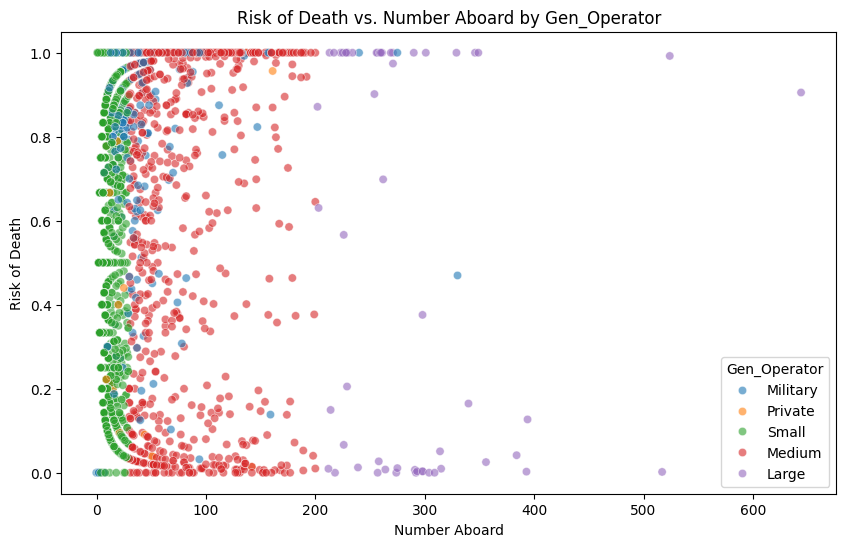

In [192]:
# Scatter plot of Risk_of_Death vs. Aboard for all Gen_Operators

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Aboard', y='Risk_of_Death', hue='Gen_Operator', alpha=0.6)
plt.title('Risk of Death vs. Number Aboard by Gen_Operator')
plt.xlabel('Number Aboard')
plt.ylabel('Risk of Death')
plt.legend(title='Gen_Operator')

This scatter plot is a little messy, but the more people aboard the plane the more divided you risk of death is. the military and private flights are mixed in with small medium and large flights.

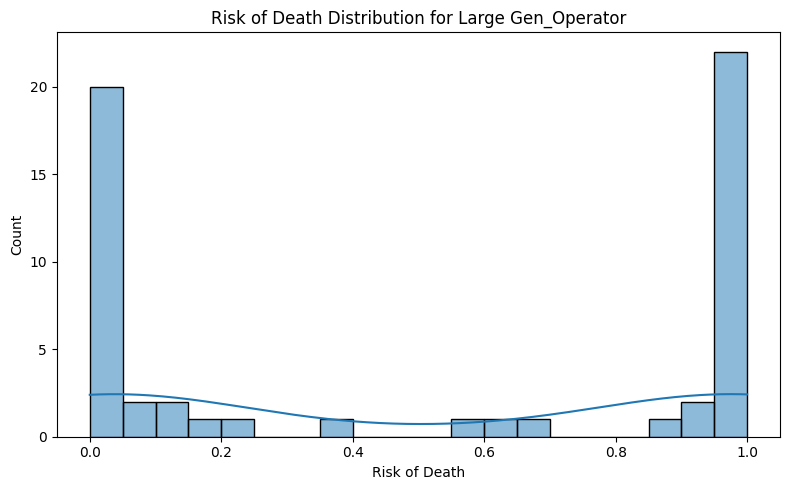

In [193]:
# Histogram of Risk_of_Death for Gen_Operator == 'Large'

plt.figure(figsize=(8, 5))
sns.histplot(df[df['Gen_Operator'] == 'Large']['Risk_of_Death'], bins=20, kde=True)
plt.title('Risk of Death Distribution for Large Gen_Operator')
plt.xlabel('Risk of Death')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

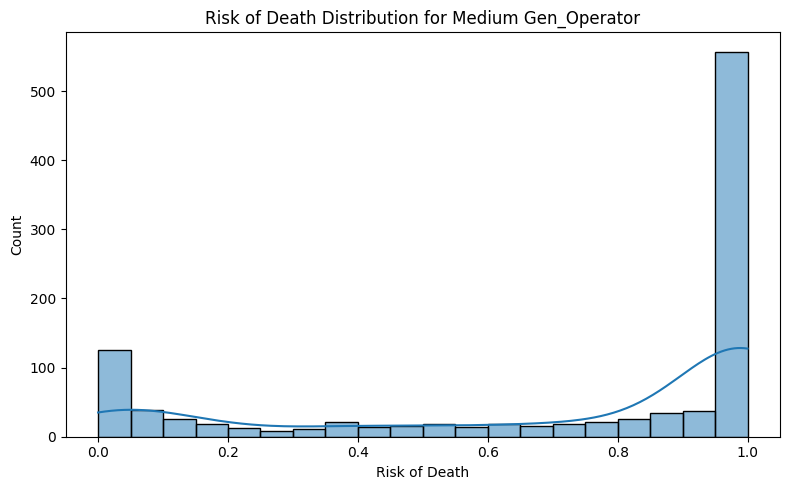

In [194]:
# Histogram of Risk_of_Death for Gen_Operator == 'Medium'

plt.figure(figsize=(8, 5))
sns.histplot(df[df['Gen_Operator'] == 'Medium']['Risk_of_Death'], bins=20, kde=True)
plt.title('Risk of Death Distribution for Medium Gen_Operator')
plt.xlabel('Risk of Death')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

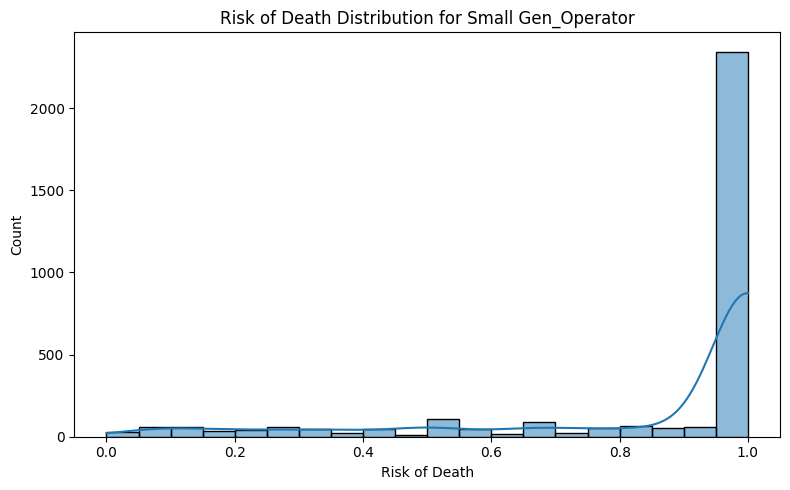

In [195]:
# Histogram of Risk_of_Death for Gen_Operator == 'Small'

plt.figure(figsize=(8, 5))
sns.histplot(df[df['Gen_Operator'] == 'Small']['Risk_of_Death'], bins=20, kde=True)
plt.title('Risk of Death Distribution for Small Gen_Operator')
plt.xlabel('Risk of Death')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

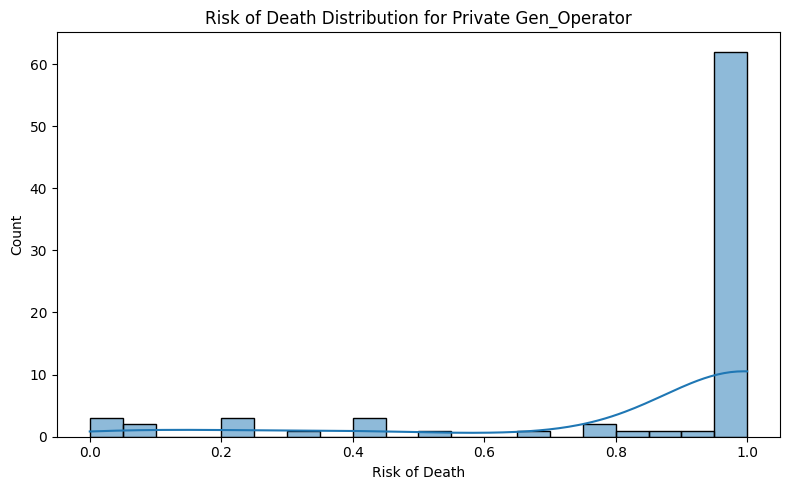

In [196]:
# Histogram of Risk_of_Death for Gen_Operator == 'Private'

plt.figure(figsize=(8, 5))
sns.histplot(df[df['Gen_Operator'] == 'Private']['Risk_of_Death'], bins=20, kde=True)
plt.title('Risk of Death Distribution for Private Gen_Operator')
plt.xlabel('Risk of Death')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

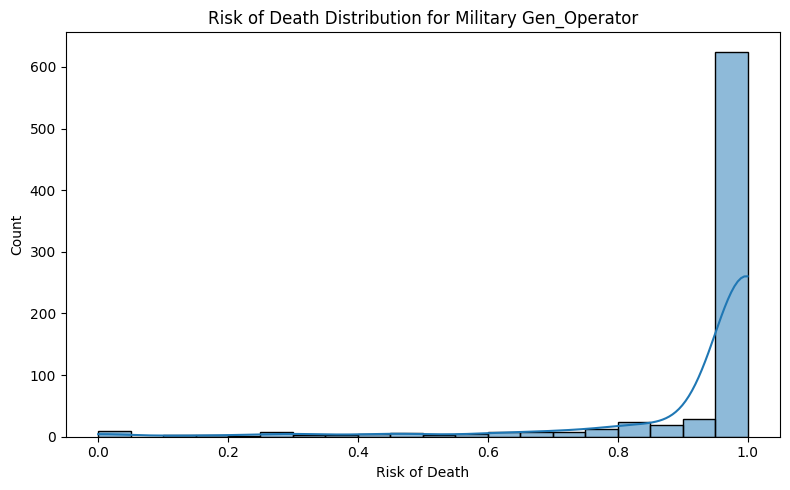

In [197]:
# Histogram of Risk_of_Death for Gen_Operator == 'Military'

plt.figure(figsize=(8, 5))
sns.histplot(df[df['Gen_Operator'] == 'Military']['Risk_of_Death'], bins=20, kde=True)
plt.title('Risk of Death Distribution for Military Gen_Operator')
plt.xlabel('Risk of Death')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

Based on these Histograms you can see the measured means from before. Large planes have about a 50% chance that everyone or no one will die in a crash. Then the chance no one will die decreases with each catagory.

In [198]:
# Group by Gen_Operator and calculate the percentage of crashes where Risk_of_Death == 1

risk_1_pct = (
    df.groupby('Gen_Operator')['Risk_of_Death']
    .apply(lambda x: (x == 1).mean() * 100)
    .sort_values(ascending=False)
)

print(risk_1_pct)

Gen_Operator
Military    77.150193
Private     75.308642
Small       71.010070
Medium      47.722960
Large       36.363636
Name: Risk_of_Death, dtype: float64


These statistics show the risk that everyone on the plane will die in a crash. about 1 out of three large planes result in 100% fatalites, and almost half of medium planes do. The other catagories have 3/4 of crashes resulting in 100% fatalities. You can also see this in the histograms.

So your chance of dying in a large plane crash or we could say normal commercial flight is about a coin toss. However, the probablity that everyone dies is 1/3. So you have a 50% chance of death, but everyone together only have 1/3 chance of death. You can apply these statistcs to the rest of the catagories

Chance of 100% fatality

Military    76.952625
Private     75.308642
Small       71.010070
Medium      46.834264
Large       36.363636

Mean risk of death accross all catagories

Military    0.929199
Private     0.860881
Small       0.855066
Medium      0.701164
Large       0.506276

To our final question, are some days or times more dangerous than others?

In [199]:
# Convert the 'Date' column to datetime format
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Date'].head()

# Convert the 'Time' column to time format (if it exists)
df['Time'] = pd.to_datetime(df['Time'], errors='coerce').dt.time
df['Time'].head()

C:\Users\goatf\AppData\Local\Temp\ipykernel_22568\2539615957.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Time'] = pd.to_datetime(df['Time'], errors='coerce').dt.time


0    17:18:00
1    06:30:00
2         NaT
3    18:30:00
4    10:30:00
Name: Time, dtype: object

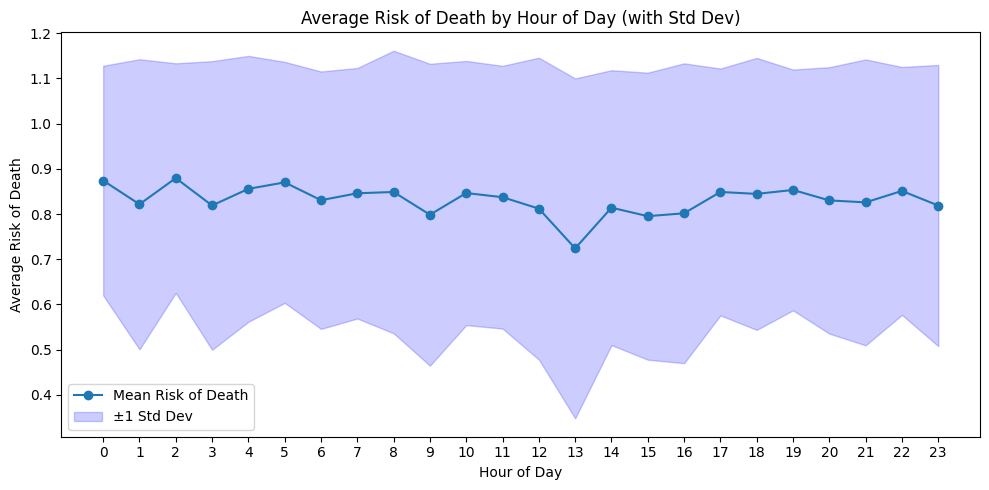

In [200]:
# Group by hour and plot average Risk_of_Death by hour, including standard deviation as a shaded area

# Remove rows with missing or invalid Time values
df_time = df.dropna(subset=['Time']).copy()

# Extract hour from 'Time'
df_time['Hour'] = df_time['Time'].apply(lambda t: t.hour)

# Group by hour and calculate mean and std of Risk_of_Death
risk_by_hour_mean = df_time.groupby('Hour')['Risk_of_Death'].mean()
risk_by_hour_std = df_time.groupby('Hour')['Risk_of_Death'].std()

plt.figure(figsize=(10, 5))
plt.plot(risk_by_hour_mean.index, risk_by_hour_mean.values, marker='o', label='Mean Risk of Death')
plt.fill_between(
    risk_by_hour_mean.index,
    risk_by_hour_mean - risk_by_hour_std,
    risk_by_hour_mean + risk_by_hour_std,
    color='b',
    alpha=0.2,
    label='±1 Std Dev'
)
plt.title('Average Risk of Death by Hour of Day (with Std Dev)')
plt.xlabel('Hour of Day')
plt.ylabel('Average Risk of Death')
plt.xticks(range(0, 24))
plt.legend()
plt.tight_layout()
plt.show()

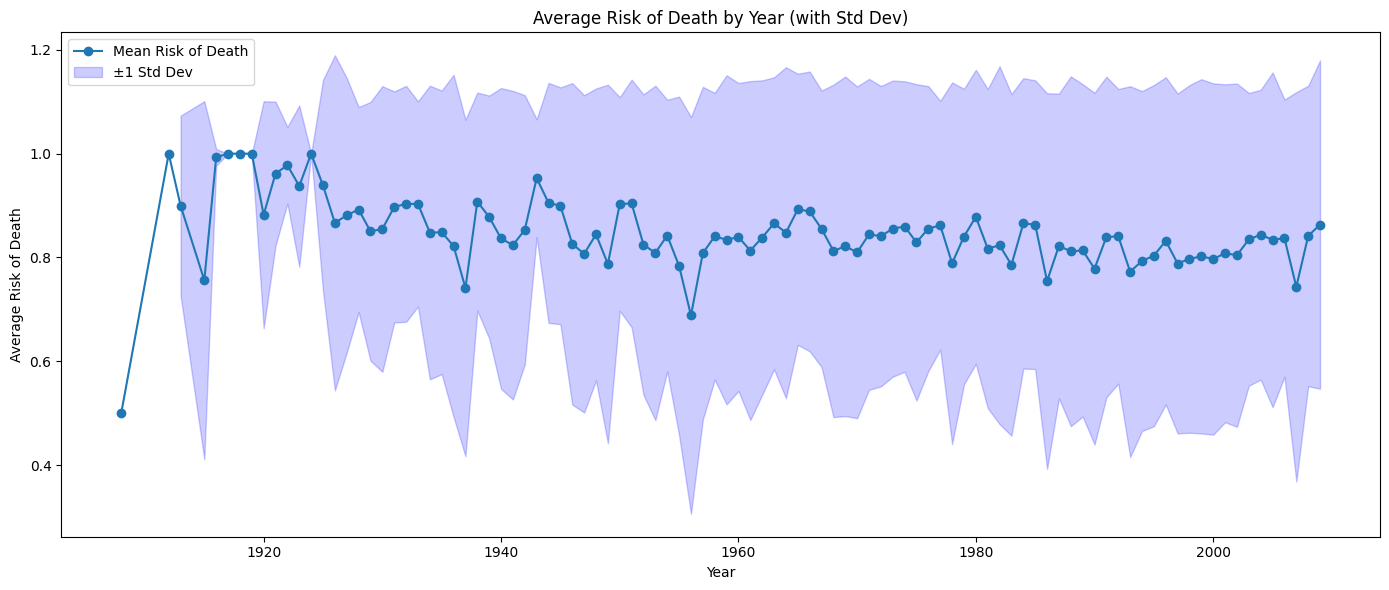

In [202]:
# Group by year and plot average Risk_of_Death by year, including standard deviation as a shaded area
df['Year'] = df['Date'].dt.year
# Group by Year and calculate mean and std of Risk_of_Death
risk_by_year_mean = df.groupby('Year')['Risk_of_Death'].mean()
risk_by_year_std = df.groupby('Year')['Risk_of_Death'].std()

plt.figure(figsize=(14, 6))
plt.plot(risk_by_year_mean.index, risk_by_year_mean.values, marker='o', label='Mean Risk of Death')
plt.fill_between(
    risk_by_year_mean.index,
    risk_by_year_mean - risk_by_year_std,
    risk_by_year_mean + risk_by_year_std,
    color='b',
    alpha=0.2,
    label='±1 Std Dev'
)
plt.title('Average Risk of Death by Year (with Std Dev)')
plt.xlabel('Year')
plt.ylabel('Average Risk of Death')
plt.legend()
plt.tight_layout()
plt.show()

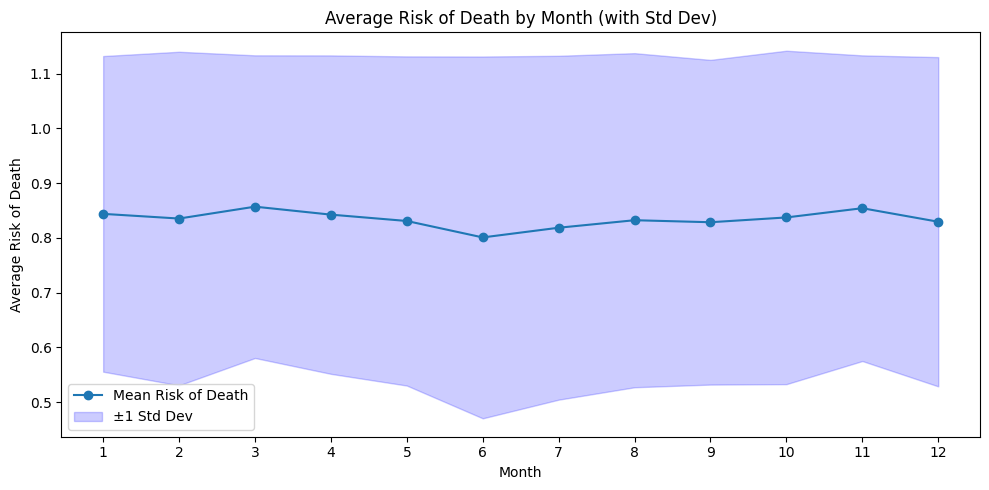

In [203]:
# Group by month and plot average Risk_of_Death by month, including standard deviation as a shaded area
df['Month'] = df['Date'].dt.month
# Group by Month and calculate mean and std of Risk_of_Death
risk_by_month_mean = df.groupby('Month')['Risk_of_Death'].mean()
risk_by_month_std = df.groupby('Month')['Risk_of_Death'].std()

plt.figure(figsize=(10, 5))
plt.plot(risk_by_month_mean.index, risk_by_month_mean.values, marker='o', label='Mean Risk of Death')
plt.fill_between(
    risk_by_month_mean.index,
    risk_by_month_mean - risk_by_month_std,
    risk_by_month_mean + risk_by_month_std,
    color='b',
    alpha=0.2,
    label='±1 Std Dev'
)
plt.title('Average Risk of Death by Month (with Std Dev)')
plt.xlabel('Month')
plt.ylabel('Average Risk of Death')
plt.xticks(range(1, 13))
plt.legend()
plt.tight_layout()
plt.show()

It does not look like the time of day, month, or year significantly affects the risk of death. You can tell by the Standard deviation in the shaded blue area, all points are within 1 Standard deviation.

In [173]:
# List unique locations in the dataset

unique_locations = df['Location'].unique()
print(len(unique_locations))

4289


There are about 5000 rows in this data set and there are 4304 unique locations, so looking at the locations would not help unless we divided them into countries or other areas. Likewise we cannot see what planes are safest to ride in because this dataset only contains plane models and types that have crashed. The planes that are not in this data set are statistically the safest to ride in.